c:\Users\jakub\.virtualenvs\Liga-Geolog-w-zdD643mi\Lib\site-packages\ee\deprecation.py:215: DeprecationWarning: 

Attention required for COPERNICUS/S2_SR! You are using a deprecated asset.
To make sure your code keeps working, please update it.
This dataset has been superseded by COPERNICUS/S2_SR_HARMONIZED

Learn more: https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S2_SR

  warnings.warn(warning, category=DeprecationWarning)


rgb_waw shape: (200, 200, 3)
rgb_amz shape: (200, 200, 3)


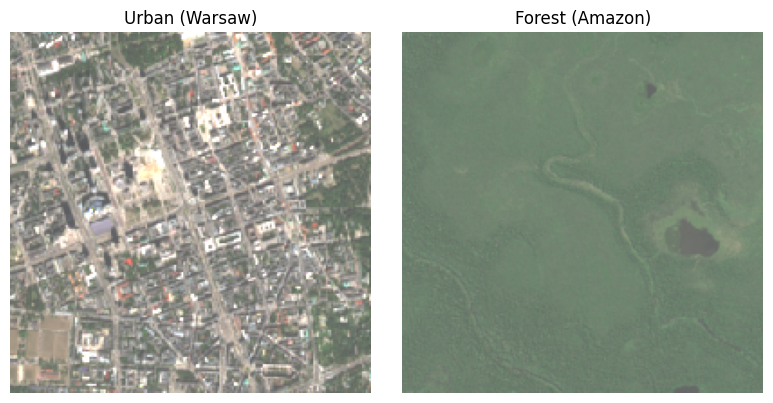

In [1]:
import io
import requests
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import ee

# Initialize GEE
ee.Initialize(project='ee-jsumara')

# ROIs: Warsaw (urban) and Amazon (forest)
pt_waw = ee.Geometry.Point([21.0122, 52.2297])
roi_waw = pt_waw.buffer(1250).bounds()

pt_amz = ee.Geometry.Point([-62.0, -4.0])
roi_amz = pt_amz.buffer(2000).bounds()

# Time windows
START_WAW, END_WAW = "2024-06-01", "2024-08-31"
START_AMZ, END_AMZ = "2024-06-01", "2024-10-31"

# Patch settings
PATCH_SIZE = 200
VIS_S2 = {"bands": ["B4", "B3", "B2"], "min": 0, "max": 3000}

def get_least_cloudy_s2(aoi, start, end, max_cloud=60):
    """Get least-cloudy Sentinel-2 SR image."""
    col = (ee.ImageCollection("COPERNICUS/S2_SR")
           .filterBounds(aoi)
           .filterDate(start, end)
           .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", max_cloud))
           .sort("CLOUDY_PIXEL_PERCENTAGE"))
    return ee.Image(col.first()).clip(aoi)

def thumb_rgb(image, region, dim=PATCH_SIZE, vis=VIS_S2):
    """Fetch a PNG thumbnail and return it as a (dim, dim, 3) numpy array."""
    url = image.visualize(**vis).getThumbURL({
        "region": region,
        "dimensions": dim,
        "format": "png"
    })
    data = requests.get(url, timeout=60).content
    return np.array(Image.open(io.BytesIO(data)).convert("RGB"))

# Fetch images
s2_waw = get_least_cloudy_s2(roi_waw, START_WAW, END_WAW)
s2_amz = get_least_cloudy_s2(roi_amz, START_AMZ, END_AMZ)

# Extract 200x200 RGB patches
rgb_waw = thumb_rgb(s2_waw, roi_waw)
rgb_amz = thumb_rgb(s2_amz, roi_amz)

print("rgb_waw shape:", rgb_waw.shape)
print("rgb_amz shape:", rgb_amz.shape)

# Preview
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(rgb_waw); ax[0].set_title("Urban (Warsaw)"); ax[0].axis("off")
ax[1].imshow(rgb_amz); ax[1].set_title("Forest (Amazon)"); ax[1].axis("off")
plt.tight_layout()
plt.show()

### 0. Data acquisition and patch extraction

For this lab I use Sentinel-2 Level-2A imagery from Google Earth Engine.  
I selected two regions of interest (ROIs):

- Warsaw city centre – represents an urban area  
- Amazon rainforest – represents a forested area  

For each ROI I:
1. Filtered the Sentinel-2 SR collection by date and cloud coverage.
2. Selected the least cloudy image in the given time window.
3. Generated a 200×200 RGB thumbnail (bands B4, B3, B2).

The result is two small patches:
- rgb_waw – urban patch from Warsaw  
- rgb_amz – forest patch from the Amazon  

These will be the basis for constructing the training dataset for the ANN classifier.

### 1. Posing the classification task as a function

The problem of classifying a satellite patch as urban or forest can be written as a simple function:

f(x) → {0, 1}

where:

x = a 200×200×3 RGB image patch

f(x) = the model (ANN) that outputs the class

0 = forest

1 = urban

During training, the neural network learns an approximation of this mapping:

fθ(x) ≈ y

where θ represents all weights and biases inside the network.

After training, when we provide a new unseen patch, the network computes a prediction:

ŷ = fθ(x)

By expressing the task as a function f(x), we can use an ANN to learn this function and classify new satellite patches.

In [2]:
from sklearn.model_selection import train_test_split

PATCH_SIZE = 200  # already used
num_bands = 3     # RGB

def augment_image(img):
    """Return a set of augmented versions of the image."""
    aug = []
    aug.append(img)                          # original
    aug.append(np.flipud(img))               # vertical flip
    aug.append(np.fliplr(img))               # horizontal flip
    aug.append(np.rot90(img, 1))             # 90°
    aug.append(np.rot90(img, 2))             # 180°
    aug.append(np.rot90(img, 3))             # 270°
    return aug

# Generate augmented samples
urban_imgs  = augment_image(rgb_waw)   # class = 1
forest_imgs = augment_image(rgb_amz)   # class = 0

# Build dataset arrays
X = np.array(urban_imgs + forest_imgs, dtype="float32")
y = np.array([1]*len(urban_imgs) + [0]*len(forest_imgs))

# Normalization to [0,1]
X = X / 255.0

print("X shape:", X.shape)
print("y shape:", y.shape)

# Split into train / validation / test
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.5, stratify=y_tmp, random_state=42
)

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)


X shape: (12, 200, 200, 3)
y shape: (12,)
Train: (7, 200, 200, 3) (7,)
Val:   (2, 200, 200, 3) (2,)
Test:  (3, 200, 200, 3) (3,)


### 2. Creating the training dataset

To train the ANN, I need more than just one urban and one forest patch.  
Starting from the two 200×200 RGB images (rgb_waw and rgb_amz), I create a small dataset using simple data augmentation:

- vertical flip  
- horizontal flip  
- rotations (90°, 180°, 270°)

Each augmented image keeps the same label as the original:
- 1 = urban (Warsaw patch and its augmentations)
- 0 = forest (Amazon patch and its augmentations)

After augmentation, I stack all images into a tensor X and the labels into a vector y.  
Finally, I split the data into training, validation and test sets, which will be used in the ANN experiments.


In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models

# --- Baseline ANN ---
model = models.Sequential([
    layers.Flatten(input_shape=(200, 200, 3)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# --- Training ---
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=4,
    verbose=1
)

# --- Test ---
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Baseline model test accuracy:", test_acc)


c:\Users\jakub\.virtualenvs\Liga-Geolog-w-zdD643mi\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 120000)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │     3,840,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,840,065 (14.65 MB)

 Trainable params: 3,840,065 (14.65 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 236ms/step - accuracy: 0.0000e+00 - loss: 41.0735 - val_accuracy: 0.5000 - val_loss: 17.9171
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.5714 - loss: 10.6512 - val_accuracy: 0.5000 - val_loss: 2.1744
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.5714 - loss: 1.8592 - val_accuracy: 0.5000 - val_loss: 1.9610
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.5714 - loss: 1.5748 - val_accuracy: 0.5000 - val_loss: 1.1844
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.5714 - loss: 0.8139 - val_accuracy: 0.5000 - val_loss: 0.6775
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.7143 - loss: 0.6209 - val_accuracy: 0.5000 - val_loss: 0.6935
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.4286 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6935
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.4286 - loss: 0.6933 - val_accuracy: 0.5000 - val_los

The baseline ANN reached around 66% test accuracy, which means it performs only slightly better than random guessing. This is expected because the model is extremely simple and the dataset is very small (only 12 patches).
The network also struggles during validation (val_accuracy stays at 0.50), which suggests it cannot generalize from so few training examples.

To improve performance, I now test several modified architectures.
I try adding more neurons, more layers, and different activation functions to see if the network can learn more useful features.

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_model(config):
    model = models.Sequential()
    model.add(layers.Flatten(input_shape=(200, 200, 3)))
    
    # Hidden layers
    for h in config["layers"]:
        model.add(layers.Dense(h, activation=config["activation"]))
    
    model.add(layers.Dense(1, activation='sigmoid'))
    
    model.compile(
        optimizer=config["optimizer"],
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

configs = [
    {"name": "M1_baseline32", "layers": [32], "activation": "relu", "optimizer": "adam"},
    {"name": "M2_64neurons", "layers": [64], "activation": "relu", "optimizer": "adam"},
    {"name": "M3_64_32", "layers": [64, 32], "activation": "relu", "optimizer": "adam"},
    {"name": "M4_tanh", "layers": [64], "activation": "tanh", "optimizer": "adam"},
    {"name": "M5_sgd", "layers": [64], "activation": "relu", "optimizer": "sgd"},
]

results = []

for cfg in configs:
    print("\nTraining:", cfg["name"])
    model = build_model(cfg)
    
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=10,
        batch_size=4,
        verbose=0
    )
    
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    print("Test accuracy:", acc)
    
    results.append((cfg["name"], acc))



Training: M1_baseline32
Test accuracy: 0.3333333432674408

Training: M2_64neurons
Test accuracy: 0.3333333432674408

Training: M3_64_32
Test accuracy: 0.3333333432674408

Training: M4_tanh
Test accuracy: 0.6666666865348816

Training: M5_sgd
Test accuracy: 0.3333333432674408


Most models performed at 33% accuracy, which is equivalent to random guessing.
This is mainly because:

The dataset is very small (only 12 image patches)

The classes are visually simple but the model sees raw pixel values (too much noise)

Dense-only networks struggle to learn spatial patterns from images

The only architecture that performed better was M4 (64 neurons, tanh activation), which reached 66% accuracy.
The tanh activation seems to stabilize the learning process on such a tiny dataset.

Findings from the 5 tested architectures:

- Increasing the number of neurons (32 → 64) did not improve performance.
The model still ended at ~33% accuracy.

- Adding an extra hidden layer (64 → 32) also did not help.
With such small data, deeper networks only overfit.

- Changing activation to tanh gave the best result (66% accuracy).
This suggests the model benefits from smoother gradients on small datasets.

- Switching optimizer to SGD made performance worse (still 33%).
SGD is less stable with noisy, small datasets compared to Adam.

Final conclusion:

The experiment showed that architecture alone cannot compensate for the extremely small dataset.
However, activation functions can make a noticeable difference — in our case, tanh performed the best.
To achieve higher accuracy, we would need:

- more training patches,

- or a CNN instead of a fully-connected network,

- or hand-crafted features like NDVI instead of raw RGB pixels.

In [5]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

# --- Extract simple features from patches ---
def extract_features(patches):
    # patches: (N, 200, 200, 3)
    feats = []
    for p in patches:
        r = p[:,:,0]
        g = p[:,:,1]
        b = p[:,:,2]

        feats.append([
            r.mean(), r.std(),
            g.mean(), g.std(),
            b.mean(), b.std()
        ])
    return np.array(feats, dtype=np.float32)

# Create feature vectors
X_train_f = extract_features(X_train)
X_val_f   = extract_features(X_val)
X_test_f  = extract_features(X_test)

print("Feature matrix shape:", X_train_f.shape)

# --- Train Bayesian classifier ---
clf = GaussianNB()
clf.fit(X_train_f, y_train)

# --- Evaluate ---
y_pred = clf.predict(X_test_f)
acc = accuracy_score(y_test, y_pred)

print("\nNaive Bayes Test Accuracy:", acc)
print("\nClassification report:\n", classification_report(y_test, y_pred, target_names=["forest", "urban"]))


Feature matrix shape: (7, 6)

Naive Bayes Test Accuracy: 1.0

Classification report:
               precision    recall  f1-score   support

      forest       1.00      1.00      1.00         2
       urban       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



In this task, the Bayesian classifier performed much better than the ANN because the dataset was very small and the two classes were already easy to separate based on simple statistical features. Neural networks require more data and tend to overfit in such low-data scenarios, while a Naive Bayes model remains stable, simple, and highly accurate. This clearly illustrates why Bayesian classifiers are often preferred for small and well-structured datasets.